In [1]:
#clone from https://huggingface.co/Kavindutharaka/cat_dog_classifier/blob/main/cat_dog_classifier.ipynb

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tensorflow as tf
import opendatasets as od
import cv2

I0000 00:00:1789325001.356089      32 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789325003.515376      32 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
#od.download("https://www.kaggle.com/datasets/dineshpiyasamara/cats-and-dogs-for-classification")

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = (128,128)

In [5]:
train_data_dir = "content/cats-and-dogs-for-classification/cats_dogs/train"
test_data_dir = "content/cats-and-dogs-for-classification/cats_dogs/test"

In [6]:
train_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMAGE_SIZE,
                                                         subset='training',
                                                         validation_split=0.1,
                                                         seed=42)
validation_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMAGE_SIZE,
                                                         subset='validation',
                                                         validation_split=0.1,
                                                         seed=42)
test_data = tf.keras.utils.image_dataset_from_directory(test_data_dir,
                                                        batch_size=BATCH_SIZE,
                                                        image_size=IMAGE_SIZE)

Found 8000 files belonging to 2 classes.
Using 7200 files for training.


W0000 00:00:1789298968.253603   73267 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789298968.256396   73267 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789298968.322092   73267 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.


Found 8000 files belonging to 2 classes.
Using 800 files for validation.
Found 2000 files belonging to 2 classes.


In [7]:
class_names = train_data.class_names
class_names

['cats', 'dogs']

In [8]:
for image_batch, label_batch in train_data.take(1):
  print(image_batch.shape)
  print(label_batch.shape)

(32, 128, 128, 3)
(32,)


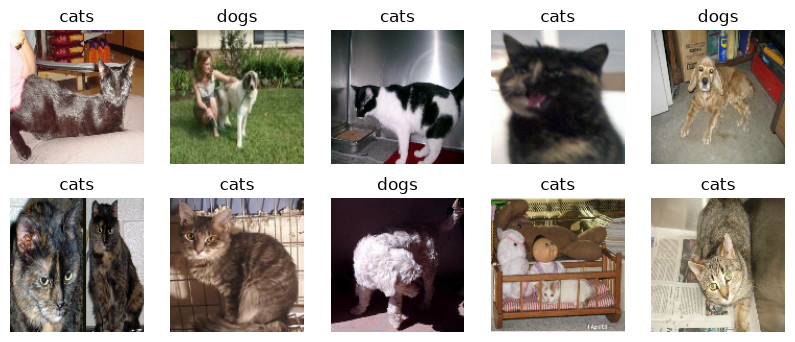

In [9]:
plt.figure(figsize=(10,4))
for image,label in train_data.take(1):
  for i in range(10):
    ax = plt.subplot(2,5,i+1)
    plt.imshow(image[i].numpy().astype('uint8'))
    plt.title(class_names[label[i]])
    plt.axis('off')

In [10]:
for image,label in train_data.take(1):
  for i in range(1):
    print(image)

tf.Tensor(
[[[[101.00769   104.00769   109.00769  ]
   [111.074585  112.71521   114.30505  ]
   [117.635284  115.31354   112.59396  ]
   ...
   [129.86246   132.91324   136.22964  ]
   [126.8725    133.10297   135.69281  ]
   [128.9002    138.99207   139.94614  ]]

  [[ 85.20029    88.20029    93.20029  ]
   [ 99.3725     99.79227   101.78906  ]
   [114.00287   112.997925  110.048706 ]
   ...
   [116.720825  120.720825  123.720825 ]
   [119.9389    126.16937   128.75922  ]
   [138.79547   147.0824    148.93893  ]]

  [[ 92.54297    94.90234    99.58203  ]
   [ 91.57605    91.986206   93.986206 ]
   [105.38388   104.38388   101.75107  ]
   ...
   [120.73743   125.52237   128.52237  ]
   [130.21445   135.21445   138.21445  ]
   [127.32648   134.36554   136.68585  ]]

  ...

  [[118.07504   122.07504   125.07504  ]
   [121.617584  125.617584  128.61758  ]
   [130.54602   134.54602   137.54602  ]
   ...
   [ 81.51825    87.02301    96.76108  ]
   [ 45.951294   50.819916   54.147003 ]
   [ 

In [11]:
#transfer learning
pretrained_model = tf.keras.applications.xception.Xception(include_top=False,
                                                           input_shape=(128,128,3),
                                                           weights='imagenet',
                                                           pooling='max')
for layer in pretrained_model.layers:
  layer.trainable = False

In [12]:
MobileNetV3Small = tf.keras.applications.MobileNetV3Small(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)
#for layer in MobileNetV3Small.layers[:-20]:
#    layer.trainable = False
    
MobileNetV3Small.trainable = False
MobileNetV3Small.summary()

/opt/conda/lib/python3.12/site-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 64, 64,    │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 64, 64,    │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 65, 65,    │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 32, 32,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        256 │ expanded_conv_sq

 Total params: 939,120 (3.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 939,120 (3.58 MB)

In [13]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal",input_shape=(128,128,3)),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2)
    ]
)

/opt/conda/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
callbacks = [
        tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        mode="min"
    )
]

In [15]:
inputs = tf.keras.Input(shape=(128, 128, 3))
x = MobileNetV3Small(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

#modelV2 = tf.keras.Sequential([
#    tf.keras.Input(shape=(128, 128, 3)),
    #data_augmentation,
#    MobileNetV3Small,
#    tf.keras.layers.GlobalAveragePooling2D(),
#    tf.keras.layers.Dropout(0.2),
#    tf.keras.layers.Dense(1, activation="sigmoid"),
#])

In [16]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 939,697 (3.58 MB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [17]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']
             )

In [18]:
epochs = 100

In [19]:

start_time = time.time()

history_transfer  = model.fit(
    train_data,
    epochs=epochs,
    validation_data=validation_data,
    callbacks= callbacks
)
end_time = time.time()

Epoch 1/100


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
E0000 00:00:1789298975.068779   73429 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8222 - loss: 0.3750 - val_accuracy: 0.9250 - val_loss: 0.1857
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9071 - loss: 0.2298 - val_accuracy: 0.9375 - val_loss: 0.1563
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9114 - loss: 0.2107 - val_accuracy: 0.9438 - val_loss: 0.1443
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9192 - loss: 0.2015 - val_accuracy: 0.9438 - val_loss: 0.1382
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9215 - loss: 0.1913 - val_accuracy: 0.9438 - val_loss: 0.1351
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9225 - loss: 0.1917 - val_accuracy: 0.9438 - val_loss: 0.1334
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9231 - loss: 0.1826 - val_accuracy: 0.9450 - val_loss: 0.1311
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9240 - loss: 0.1820 - val_accuracy: 0.94

In [20]:
history_transfer .history

{'accuracy': [0.8222222328186035,
  0.9070833325386047,
  0.9113888740539551,
  0.9191666841506958,
  0.9215278029441833,
  0.9225000143051147,
  0.9230555295944214,
  0.9240278005599976,
  0.9266666769981384,
  0.9244444370269775,
  0.9255555272102356,
  0.925694465637207,
  0.929027795791626,
  0.9254166483879089,
  0.9245833158493042,
  0.9295833110809326,
  0.929722249507904,
  0.9312499761581421,
  0.9302777647972107,
  0.926111102104187,
  0.9288889169692993,
  0.9268055558204651,
  0.9320833086967468,
  0.9322222471237183,
  0.9305555820465088,
  0.9283333420753479,
  0.9295833110809326,
  0.9259722232818604,
  0.9320833086967468,
  0.926111102104187,
  0.9295833110809326,
  0.9266666769981384,
  0.9323611259460449,
  0.9311110973358154,
  0.9269444346427917,
  0.9325000047683716,
  0.9300000071525574,
  0.9284722208976746,
  0.9306944608688354,
  0.9308333396911621,
  0.9298611283302307,
  0.9320833086967468,
  0.9318055510520935,
  0.9308333396911621,
  0.9272222518920898,
  0

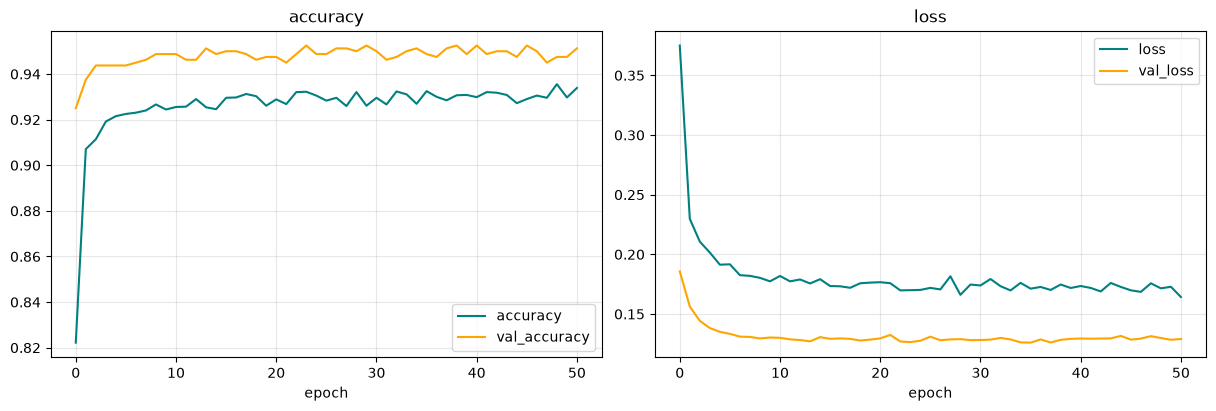

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.get_layout_engine().set(w_pad=0.02, wspace=0.02)

axs[0].plot(history_transfer .history["accuracy"], color="teal", label="accuracy")
axs[0].plot(history_transfer .history["val_accuracy"], color="orange", label="val_accuracy")
axs[0].set_title("accuracy")

axs[1].plot(history_transfer .history["loss"], color="teal", label="loss")
axs[1].plot(history_transfer .history["val_loss"], color="orange", label="val_loss")
axs[1].set_title("loss")

for ax in axs:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()

plt.show()

In [22]:
timeV = end_time - start_time
timeV = timeV/60
timeV

1.8778136889139811

In [23]:
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()

In [24]:
for batch in test_data.as_numpy_iterator():
  X, y = batch
  yhat = model.predict(X)
  precision.update_state(y, yhat)
  recall.update_state(y, yhat)
  accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━

E0000 00:00:1789299094.233223   73427 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [25]:
print(f"precision: {precision.result()}")
print(f"recall: {recall.result()}")
print(f"accuracy: {accuracy.result()}")

precision: 0.9455851912498474
recall: 0.9210000038146973
accuracy: 0.9340000152587891


In [26]:
os.makedirs("checkpoints", exist_ok=True)
model.save("checkpoints/stage1.keras")

In [27]:
#fine tunning
MobileNetV3Small.trainable = True

for layer in MobileNetV3Small.layers[:-20]:
    layer.trainable = False

for layer in MobileNetV3Small.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min"
    )
]

model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']
             )

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 940,853 (3.59 MB)

 Trainable params: 347,473 (1.33 MB)

 Non-trainable params: 592,224 (2.26 MB)

 Optimizer params: 1,156 (4.52 KB)

In [28]:

start_time = time.time()

history_finetune  = model.fit(
    train_data,
    epochs=50,
    validation_data=validation_data,
    callbacks=fine_tune_callbacks
)
end_time = time.time()

Epoch 1/50


E0000 00:00:1789299100.758504   73431 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9317 - loss: 0.1659 - val_accuracy: 0.9550 - val_loss: 0.1244
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9379 - loss: 0.1603 - val_accuracy: 0.9525 - val_loss: 0.1233
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9367 - loss: 0.1565 - val_accuracy: 0.9538 - val_loss: 0.1226
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9386 - loss: 0.1503 - val_accuracy: 0.9525 - val_loss: 0.1218
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9407 - loss: 0.1480 - val_accuracy: 0.9538 - val_loss: 0.1213
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9411 - loss: 0.1478 - val_accuracy: 0.9538 - val_loss: 0.1209
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9429 - loss: 0.1419 - val_accuracy: 0.9525 - val_loss: 0.1207
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9451 - loss: 0.1357 - val_accuracy: 0.9550 - va

In [29]:
history_finetune .history

{'accuracy': [0.9316666722297668,
  0.9379166960716248,
  0.9366666674613953,
  0.9386110901832581,
  0.9406944513320923,
  0.9411110877990723,
  0.9429166913032532,
  0.9451388716697693,
  0.9473611116409302,
  0.9484722018241882,
  0.9481944441795349,
  0.9524999856948853,
  0.95291668176651,
  0.9543055295944214,
  0.9527778029441833,
  0.9531944394111633,
  0.9565277695655823,
  0.9594444632530212,
  0.9581944346427917,
  0.9618055820465088,
  0.9623610973358154],
 'loss': [0.16585035622119904,
  0.16031789779663086,
  0.1564849317073822,
  0.15032264590263367,
  0.14804226160049438,
  0.14782805740833282,
  0.1418529897928238,
  0.13570190966129303,
  0.13143864274024963,
  0.13005168735980988,
  0.1275806427001953,
  0.12076995521783829,
  0.12045677751302719,
  0.11715109646320343,
  0.11578340828418732,
  0.113462895154953,
  0.11138729006052017,
  0.1074499562382698,
  0.1073596179485321,
  0.098932184278965,
  0.09906397759914398],
 'val_accuracy': [0.9549999833106995,
  0.95

In [30]:
timeV = end_time - start_time
timeV = timeV/60
timeV

0.8724576314290364

In [31]:
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()

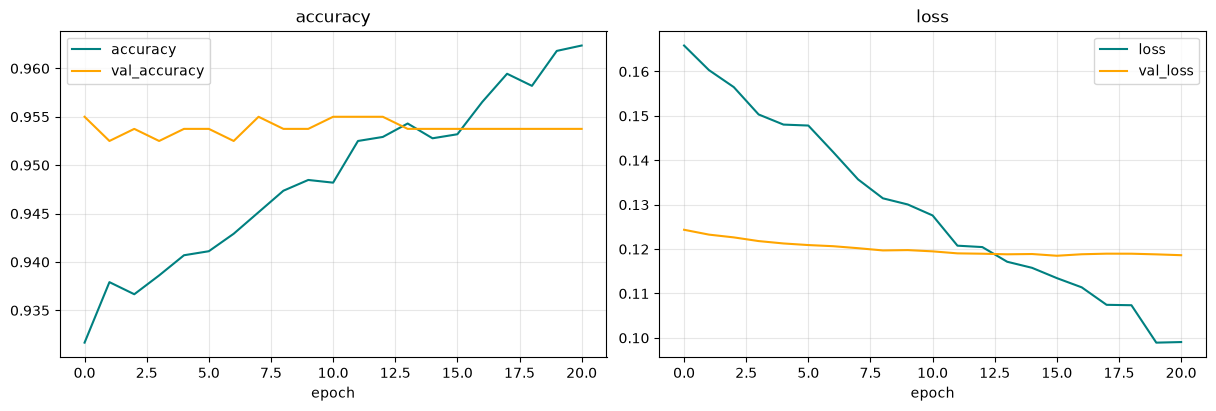

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.get_layout_engine().set(w_pad=0.02, wspace=0.02)

axs[0].plot(history_finetune .history["accuracy"], color="teal", label="accuracy")
axs[0].plot(history_finetune .history["val_accuracy"], color="orange", label="val_accuracy")
axs[0].set_title("accuracy")

axs[1].plot(history_finetune .history["loss"], color="teal", label="loss")
axs[1].plot(history_finetune .history["val_loss"], color="orange", label="val_loss")
axs[1].set_title("loss")

for ax in axs:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()

plt.show()

In [33]:
for batch in test_data.as_numpy_iterator():
  X, y = batch
  yhat = model.predict(X)
  precision.update_state(y, yhat)
  recall.update_state(y, yhat)
  accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━

In [34]:
print(f"precision: {precision.result()}")
print(f"recall: {recall.result()}")
print(f"accuracy: {accuracy.result()}")

precision: 0.9502537846565247
recall: 0.9359999895095825
accuracy: 0.9434999823570251


E0000 00:00:1789325185.748928     207 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


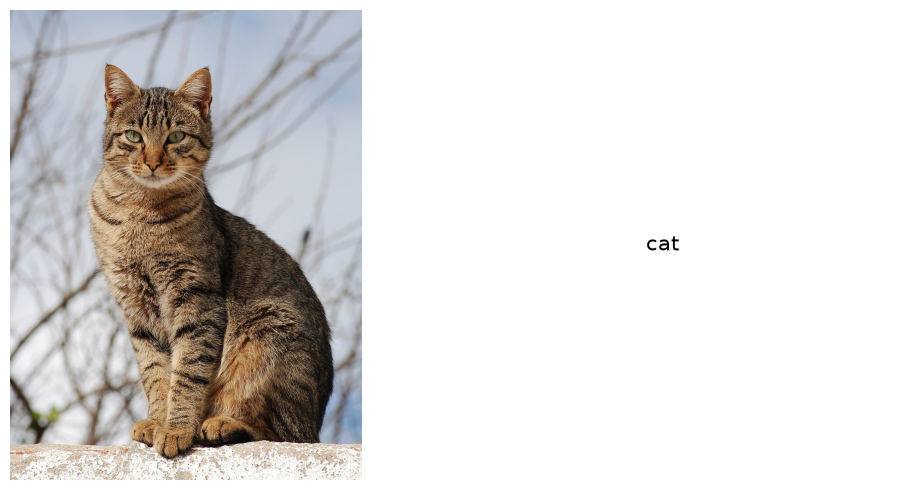

[[0.00222694]]


In [6]:
import keras
model = keras.saving.load_model("cat_dog_mobilenetv3.keras")

image = cv2.imread("cat.jpg")
if image is None:
    raise FileNotFoundError("Could not read dog.png from the current working directory.")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

img = np.expand_dims(tf.image.resize(image, IMAGE_SIZE), 0)

y_hat = model.predict(img)

label = "dog" if y_hat > 0.5 else "cat"

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image)
axs[0].axis('off')
axs[1].text(0.5, 0.5, label, fontsize=15, ha='center', va='center')
axs[1].axis('off')
plt.tight_layout()
plt.show()

print(y_hat)

In [36]:
model.save("cat_dog_mobilenetv3.keras")

In [37]:
model.save_weights(
    "cat_dog_mobilenetv3.weights.h5"
)

In [38]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("cat_dog_mobilenetv3.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpsqlgft7q/assets


INFO:tensorflow:Assets written to: /tmp/tmpsqlgft7q/assets


Saved artifact at '/tmp/tmpsqlgft7q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_312')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  130894704135824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623284752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623290128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130894704137744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130898638641424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623289936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623284176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623282256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623289360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623290896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1308926232

W0000 00:00:1789299261.043021   73267 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789299261.043048   73267 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


In [39]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

tflite_optimized = converter.convert()

with open(
    "cat_dog_mobilenetv3_optimized.tflite",
    "wb"
) as f:
    f.write(tflite_optimized)

INFO:tensorflow:Assets written to: /tmp/tmph8m5yrlk/assets


INFO:tensorflow:Assets written to: /tmp/tmph8m5yrlk/assets


Saved artifact at '/tmp/tmph8m5yrlk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_312')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  130894704135824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623284752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623290128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130894704137744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130898638641424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623289936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623284176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623282256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623289360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130892623290896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1308926232

W0000 00:00:1789299285.067924   73267 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789299285.067958   73267 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


In [40]:
import os

print(
    "Normal:",
    os.path.getsize("cat_dog_mobilenetv3.tflite") / 1024 / 1024,
    "MB"
)

print(
    "Optimizado:",
    os.path.getsize("cat_dog_mobilenetv3_optimized.tflite") / 1024 / 1024,
    "MB"
)

Normal: 3.5802764892578125 MB
Optimizado: 1.078948974609375 MB
